# Shear modulus reconstruction - two inclusions (Fig 3.b, 4.b,c and 5.b)

In [1]:
import dolfin as df
import math
import matplotlib.pyplot as plt
import numpy as np
import os

from Isotropic_case_forward_pb import isotropic_elasticity_problem
from Isotropic_case_VFM import VFM
from Type_3_VF import type_3
from Isotropic_case_VFM import solve_VFM_2_dim
%load_ext autoreload
%autoreload 2

### True parameter mu

In [2]:
# mu_1
class Mu2Expression(df.UserExpression):
    def eval(self, value, x):
        value[0]=0
        if (x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)  <= 0.1  *0.1 :
            value[0]= 1
        elif  0.1  *0.1 <= (x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)  <= 0.15  *0.15 :
            value[0]= (1-(math.sqrt((x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)) - 0.1)/0.05 )**2*(1+2*(math.sqrt((x[0] - 0.2)*(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8))-0.1) /0.05) 
        elif (x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)  <= 0.1  *0.1 :
            value[0]= 2
        elif  0.1  *0.1 <= (x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)  <= 0.15  *0.15 :
            value[0]=2*(1-(math.sqrt((x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)) - 0.1)/0.05 )**2*(1+2*(math.sqrt((x[0] - 0.8)*(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2))-0.1) /0.05)     
        value[0] = 1+value[0]
 
mu = Mu2Expression()


### Direct problem

In [3]:
omega, rho = 1, 1
degree = 3
dim = 2
Nx = 100
Ny = 100
u_boundary = df.Constant((0,0))  
T=  df.Expression(('0', '2*sin(2*pi*x[0])'), degree=1)

f = df.Constant((0,0))
tol = 1e-15

mesh_params = {"Nx":Nx, "Ny":Ny, "degree":degree}
load_params = {"u_boundary":u_boundary, "f":f ,"T":T} 
mat_params  = {"mu":mu, "rho":rho, "omega":omega}

ureal1, mu_function, ureal1_norm = isotropic_elasticity_problem(
    mesh_params=mesh_params,
    mat_params=mat_params,
    load_params=load_params)

Solving linear variational problem.


### Plot mu

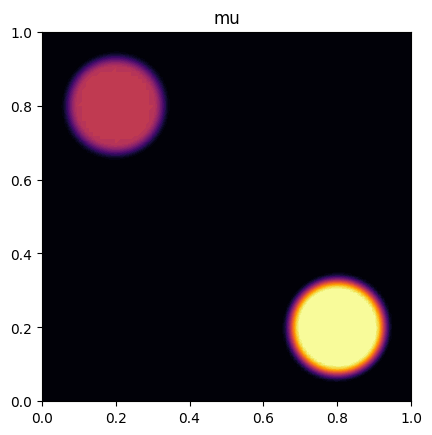

In [4]:
df.plot(mu_function, title="mu", cmap="inferno")
 

### PLot u

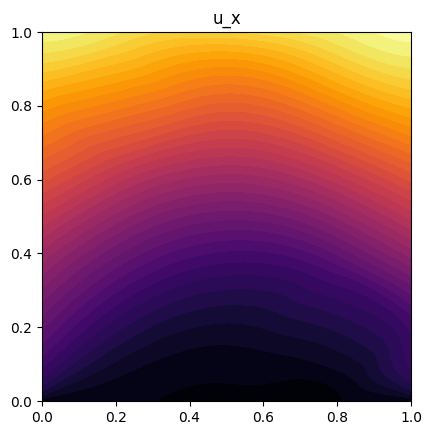

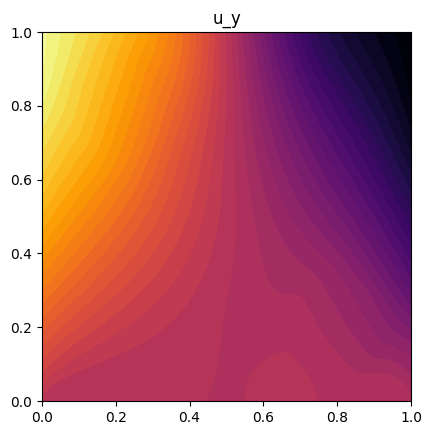

In [5]:
u1, u2 = ureal1.split()
df.plot(u1, title="u_x", cmap="inferno")
plt.show()

df.plot(u2, title="u_y", cmap="inferno")
plt.show()

## Compare the three types of virtual fields - noiseless data

In [6]:
Error_list_Type1= []
Error_list_Type2= []
Error_list_Type3= []
SNR_list= [0]
V1 = ureal1.function_space()
V_mu= mu_function.function_space()
mesh= V_mu.mesh()
dx = df.Measure("dx", domain=mesh)

phi_list = []
class phiExpression(df.UserExpression):
    def eval(self, value, x):
        value[0] = 0
        if (x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)  <= 0.1  *0.1 :
            value[0]= 1
        elif  0.1  *0.1 <= (x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)  <= 0.15  *0.15 :
            value[0]= (1-(math.sqrt((x[0] - 0.2) *(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8)) - 0.1)/0.05 )**2*(1+2*(math.sqrt((x[0] - 0.2)*(x[0] - 0.2)  + (x[1] - 0.8) *(x[1] - 0.8))-0.1) /0.05) 
phi = phiExpression()
phi= df.interpolate(phi, V_mu)
phi_list.append(phi)

class phiExpression(df.UserExpression):
    def eval(self, value, x):
        value[0] = 0
        if (x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)  <= 0.1  *0.1 :
            value[0]= 2
        elif  0.1  *0.1 <= (x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)  <= 0.15  *0.15 :
            value[0]=2*(1-(math.sqrt((x[0] - 0.8) *(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2)) - 0.1)/0.05 )**2*(1+2*(math.sqrt((x[0] - 0.8)*(x[0] - 0.8)  + (x[1] - 0.2) *(x[1] - 0.2))-0.1) /0.05)   
phi = phiExpression()
phi= df.interpolate(phi, V_mu)
phi_list.append(phi)            

Q= df.FiniteElement('CG', mesh.ufl_cell(), degree=degree - 1)
Q1 = df.FunctionSpace(mesh, Q)
V = df.VectorElement('CG', mesh.ufl_cell(), degree=degree)
V1 = df.FunctionSpace(mesh, V)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

def epsilon(u):
    return 0.5*(df.nabla_grad(u) + df.nabla_grad(u).T) 

### Type 1

In [7]:
alpha=1e10
mu_rec= VFM(phi_list, ureal1, V_mu, V, Q, alpha, rho, omega) 
norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 1, noiseless data :', norm1_l2) 
Error_list_Type1.append(norm1_l2*100)

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Values of m: [4.20718035e-09]
Solving linear variational problem.
Values of m: [1.16530154e-08]
[[1.81317986e-03 4.20720513e-14]
 [1.16530091e-13 5.02213167e-03]]
0.9999759252836328
0.9999664604440105
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 1, noiseless data : 0.00038510865630780167


### Type 3

In [8]:
T=  df.Expression(( '2*sin(2*pi*x[0])', '0'), degree=1)
load_params = {"u_boundary":u_boundary, "f":f ,"T":T} 

ureal2, mu_function, ureal2_norm = isotropic_elasticity_problem(
    mesh_params=mesh_params,
    mat_params=mat_params,
    load_params=load_params)

v2_1= type_3(mesh_params, Vertical_traction= True)
v2_2= type_3(mesh_params, Vertical_traction= False)
v2_1 = df.interpolate(v2_1, V1)
v2_2 = df.interpolate(v2_2, V1)
ureal1 = df.interpolate(ureal1, V1)
ureal2 = df.interpolate(ureal2, V1)

mu_rec = solve_VFM_2_dim(v2_1,v2_2,phi_list, ureal1,ureal2, rho, omega, V_mu)


norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 3, noiseless data :', norm1_l2) 
Error_list_Type3.append(norm1_l2*100)

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
0.9999951160146303
0.9999963570842312
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 3, noiseless data : 0.0003851663035130787


### Type 2

In [9]:
class vExpression(df.UserExpression):
       def eval(self, value, x):
          value[0] = -x[1]*x[0]*(3*x[1]-2) 
          value[1] = (x[1]**2)*(x[1]-1)
       def value_shape(self):
           return (2,)    
v1_1 = vExpression()
v1_1 = df.interpolate(v1_1, V1)

class vExpression(df.UserExpression):
       def eval(self, value, x):
          value[0] = x[1]*(x[1]-1)*x[0] 
          value[1] = (-x[1]**3/3 + x[1]**2/2)
       def value_shape(self):
           return (2,)    
v1_2 = vExpression()
v1_2 = df.interpolate(v1_2, V1)

mu_rec = solve_VFM_2_dim(v1_1,v1_2,phi_list, ureal1,ureal2, rho, omega, V_mu)

norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 2, noiseless data :', norm1_l2) 
Error_list_Type2.append(norm1_l2*100)

1.000017717747029
1.0000108691782177
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 2, noiseless data : 0.00038533708720387734


## Compare the three types of virtual fields - noisy data

In [10]:
Noise_list = np.array( [ 0.025**2, 0.05**2, 0.075**2, 0.10**2, 0.15**2, 0.16**2])
nb_noise = np.size(Noise_list)

h=ureal1.vector().get_local()
a=h.shape 


In [11]:
for k in range(nb_noise) :  
    print("Noise = ", Noise_list[k])

    class noiseExpression(df.UserExpression):
        def eval(self, value, x):
           value[0]=0
           value[1]=0  
           for m  in range(1,10) :
                value[0] = value[0] +  Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs(Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal1_norm
                value[1] = value[1] + Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs( Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal1_norm
        def value_shape(self):
           return (2,)
    
    noise_Expression= noiseExpression()
    noise_Expression= df.interpolate(noise_Expression, V1) 
    u_noised1= df.Function(V1)    
    u_noised1.vector()[:] = ureal1.vector()[:]+ noise_Expression.vector()[:] 
    
    u_noised2= df.Function(V1)    
    u_noised2.vector()[:] = ureal2.vector()[:]+ noise_Expression.vector()[:] 


    SNR = math.sqrt(df.assemble((epsilon(ureal1) - epsilon(u_noised1))**2 * dx ) + df.assemble((ureal1 - u_noised1)**2 * dx) )/ ureal1_norm 
    SNR_list.append(SNR*100)
    print("SNR", SNR)

    #Type 1:
    mu_rec= VFM(phi_list, u_noised1, V_mu, V, Q, alpha, rho, omega) 
    norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    Error_list_Type1.append(norm1_l2*100)
    print(f'L2-norm error, Type 1, noisy data {SNR}:', norm1_l2)

    #Type 2:
    mu_rec = solve_VFM_2_dim(v1_1, v1_2, phi_list, u_noised1, u_noised2, rho, omega, V_mu)
    norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    print(f'L2-norm error, Type 2, noisy data {SNR}:', norm1_l2) 
    Error_list_Type2.append(norm1_l2*100)

    #Type 3:
    mu_rec = solve_VFM_2_dim(v2_1, v2_2, phi_list, u_noised1,  u_noised2, rho, omega, V_mu)
    norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    print(f'L2-norm error, Type 3, noisy data {SNR}:', norm1_l2) 
    Error_list_Type3.append(norm1_l2*100)
    

Noise =  0.0006250000000000001
SNR 0.030060523008805455
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Values of m: [4.26936857e-09]
Solving linear variational problem.
Values of m: [1.18324069e-08]
[[1.81329325e-03 4.26939766e-14]
 [1.18324601e-13 5.02547951e-03]]
0.9941358004118777
0.9988292162082969
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 1, noisy data 0.030060523008805455: 0.001140227084027917
1.0012961069450868
0.9992760153608466
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 2, noisy data 0.030060523008805455: 0.0005065969535178844
1.0151323198278526
1.0013259110542754
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 3, noisy data 0.030060523008805455: 0.0026608159473994557
Noise =  0.0025000000000000005
SNR 0.060125243008534404
Solving line

In [12]:
print(SNR_list)
print(Error_list_Type1)
print(Error_list_Type2)
print(Error_list_Type3)

[0, 3.0060523008805453, 6.012524300853441, 8.396576356443978, 12.036027872170488, 19.482942126906146, 21.71694821679806]
[0.03851086563078017, 0.11402270840279169, 1.1908934655969687, 0.8325837468912692, 0.22227705180275, 3.9081751234834607, 5.145981436020889]
[0.038533708720387735, 0.05065969535178844, 0.44457952115513233, 3.4921592770818957, 8.7551820516031, 47.075791768267614, 68.03238810485307]
[0.03851663035130787, 0.2660815947399456, 0.7582059129521335, 3.9724766135684217, 2.4673328465062565, 7.225158566180546, 14.884451806810283]


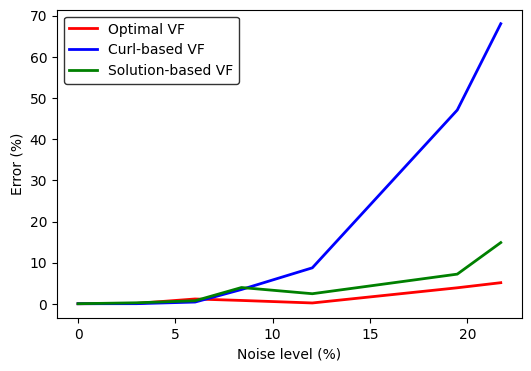

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Error_list_Type1, "-r", label="Optimal VF", linewidth=2)
ax.plot(SNR_list, Error_list_Type2, "-b", label="Curl-based VF", linewidth=2)
ax.plot(SNR_list, Error_list_Type3, "-g", label="Solution-based VF", linewidth=2)

ax.set_xlabel('Noise level (%)')
ax.set_ylabel('Error (%)')


ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
           title_fontsize=10)

plt.show()
